In [12]:
%matplotlib ipympl

from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
plt.rcParams["figure.figsize"] = (10, 4)

import pandas as pd
import numpy as np
import math
from os import path
import os
pd.options.mode.chained_assignment = None

from plots import *
from interpolate_trajectories import interpolate_pose_2d_trajectories, interpolate_pose_2d_trajectory

plot_output_path = path.expanduser("~/ds/uwb_logs/plots/")
os.makedirs(plot_output_path, exist_ok=True)

t_start = 1760013770.503812 + 25

# load tag 1 positions (ground truth (RTK) and uwb data)
tag_1 = pd.read_csv(path.expanduser("~/ds/uwb_logs/tag_1_positions.csv"))
tag_1.drop(tag_1[tag_1.q == 0].index, axis=0, inplace=True)
tag_1.drop(tag_1[tag_1.t < t_start].index, axis=0, inplace=True)

# load tag 2 positions (ground truth (RTK) and uwb data)
tag_2 = pd.read_csv(path.expanduser("~/ds/uwb_logs/tag_2_positions.csv"))
tag_2.drop(tag_2[tag_2.q == 0].index, axis=0, inplace=True)
tag_2.drop(tag_2[tag_2.t < t_start].index, axis=0, inplace=True)

tag_1_rtk = tag_1.rename(columns={'x_rtk': 'x', 'y_rtk': 'y'})[['t', 'x', 'y']]
tag_1_uwb = tag_1.rename(columns={'x_uwb': 'x', 'y_uwb': 'y'})[['t', 'x', 'y']]
tag_2_rtk = tag_2.rename(columns={'x_rtk': 'x', 'y_rtk': 'y'})[['t', 'x', 'y']]
tag_2_uwb = tag_2.rename(columns={'x_uwb': 'x', 'y_uwb': 'y'})[['t', 'x', 'y']]
tag_rtk = interpolate_pose_2d_trajectories(tag_1_rtk, tag_2_rtk, 'tag_1', 'tag_2')
tag_uwb = interpolate_pose_2d_trajectories(tag_1_uwb, tag_2_uwb, 'tag_1', 'tag_2')

# load rtk positions
rtk = pd.read_csv(path.expanduser("~/ds/uwb_logs/rtk_positions.csv"))
rtk.drop(rtk[rtk.t < t_start].index, axis=0, inplace=True)

# load ekf rtk positions
ekf_rtk = pd.read_csv(path.expanduser("~/ds/uwb_logs/ekf_rtk_positions.csv"))
ekf_rtk.drop(ekf_rtk[ekf_rtk.t < t_start].index, axis=0, inplace=True)

# load ekf uwb positions
ekf_rtk = pd.read_csv(path.expanduser("~/ds/uwb_logs/ekf_rtk_positions.csv"))
ekf_rtk.drop(ekf_rtk[ekf_rtk.t < t_start].index, axis=0, inplace=True)
ekf_uwb = pd.read_csv(path.expanduser("~/ds/uwb_logs/ekf_uwb_positions.csv"))
ekf_uwb.drop(ekf_uwb[ekf_uwb.t < t_start].index, axis=0, inplace=True)

ekf = interpolate_pose_2d_trajectories(ekf_rtk, ekf_uwb, 'rtk', 'uwb')

gnss_timestamps = rtk[['t']]

# interpolate the values around the timestamps of the GNSS corrections
tag_1_rtk_gts = interpolate_pose_2d_trajectory(gnss_timestamps, tag_1_rtk, 'tag_1_rtk')
tag_1_uwb_gts = interpolate_pose_2d_trajectory(gnss_timestamps, tag_1_uwb, 'tag_1_uwb')
tag_2_rtk_gts = interpolate_pose_2d_trajectory(gnss_timestamps, tag_2_rtk, 'tag_2_rtk')
tag_2_uwb_gts = interpolate_pose_2d_trajectory(gnss_timestamps, tag_2_uwb, 'tag_2_uwb')
ekf_uwb_gts = interpolate_pose_2d_trajectory(gnss_timestamps, ekf_uwb, 'ekf_uwb')
ekf_rtk_gts = interpolate_pose_2d_trajectory(gnss_timestamps, ekf_rtk, 'ekf_rtk')

# # interpolate ekf_uwb around rtk, to downsample the data of ekf_uwb to the timestamps of the RTK corrections
tag_1_uwb_and_rtk = interpolate_pose_2d_trajectories(rtk, tag_1_uwb, 'rtk', 'tag_1_uwb')
# print(f"mean error tag_1_uwb - rtk:\t{np.sqrt((tag_1_uwb_and_rtk.x_tag_1_uwb - tag_1_uwb_and_rtk.x_rtk)**2 + (tag_1_uwb_and_rtk.y_tag_1_uwb - tag_1_uwb_and_rtk.y_rtk)**2).mean()}")

# # interpolate ekf_uwb around rtk, to downsample the data of ekf_uwb to the timestamps of the RTK corrections
# ekf_uwb_and_rtk = interpolate_pose_2d_trajectories(rtk, ekf_uwb, 'rtk', 'ekf_uwb')
# print(f"mean error ekf_uwb - rtk:\t{np.sqrt((ekf_uwb_and_rtk.x_ekf_uwb - ekf_uwb_and_rtk.x_rtk)**2 + (ekf_uwb_and_rtk.y_ekf_uwb - ekf_uwb_and_rtk.y_rtk)**2).mean()}")

# # interpolate tag_[1,2]_rtk around rtk, to downsample the data of tag_[1,2]_rtk to the timestamps of the RTK corrections
# tag_1_rtk_and_rtk = interpolate_pose_2d_trajectories(rtk, tag_1_rtk, 'rtk', 'tag_1_rtk')
# tag_2_rtk_and_rtk = interpolate_pose_2d_trajectories(rtk, tag_2_rtk, 'rtk', 'tag_2_rtk')


/home/enrico/w/repossi_jazzy_ws/src/uwb_localization_utils/plots.py:18: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


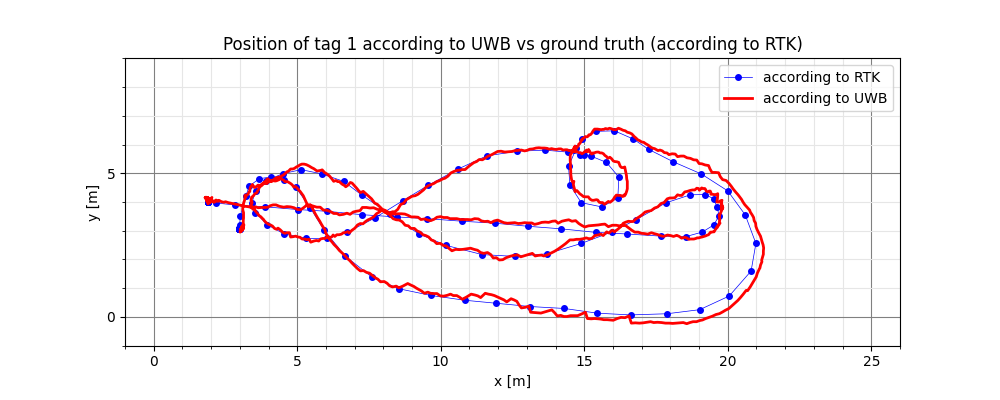

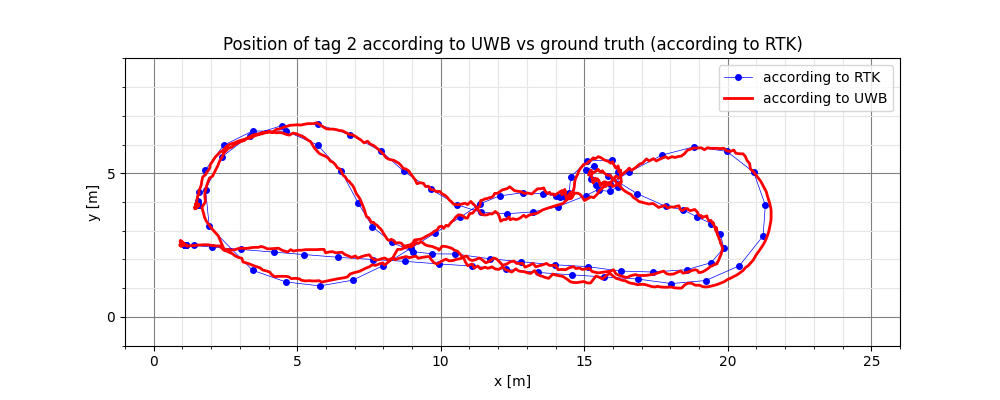

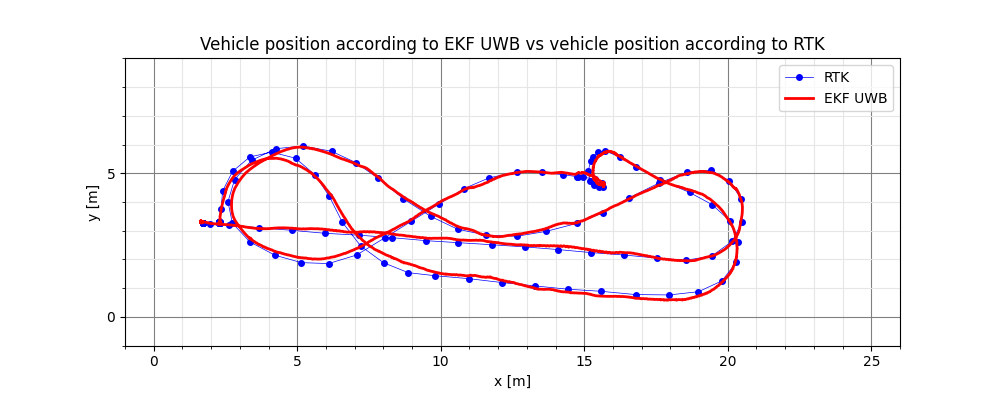

In [13]:
plot_trajectory(
    title="Position of tag 1 according to UWB vs ground truth (according to RTK)", plot_output_path=plot_output_path, marker_size=4.0,
    a_x=tag_1_rtk_gts.x, a_y=tag_1_rtk_gts.y, a_label="according to RTK", a_color="blue", a_scatter=True,
    b_x=tag_1_uwb.x, b_y=tag_1_uwb.y, b_label="according to UWB", b_color="red",
)
plot_trajectory(
    title="Position of tag 2 according to UWB vs ground truth (according to RTK)", plot_output_path=plot_output_path, marker_size=4.0,
    a_x=tag_2_rtk_gts.x, a_y=tag_2_rtk_gts.y, a_label="according to RTK", a_color="blue", a_scatter=True,
    b_x=tag_2_uwb.x, b_y=tag_2_uwb.y, b_label="according to UWB", b_color="red",
)
plot_trajectory(
    title="Vehicle position according to EKF UWB vs vehicle position according to RTK", plot_output_path=plot_output_path, marker_size=4.0,
    a_x=rtk.x, a_y=rtk.y, a_label="RTK", a_color="blue", a_scatter=True,
    b_x=ekf_uwb.x, b_y=ekf_uwb.y, b_label="EKF UWB", b_color="red",
)

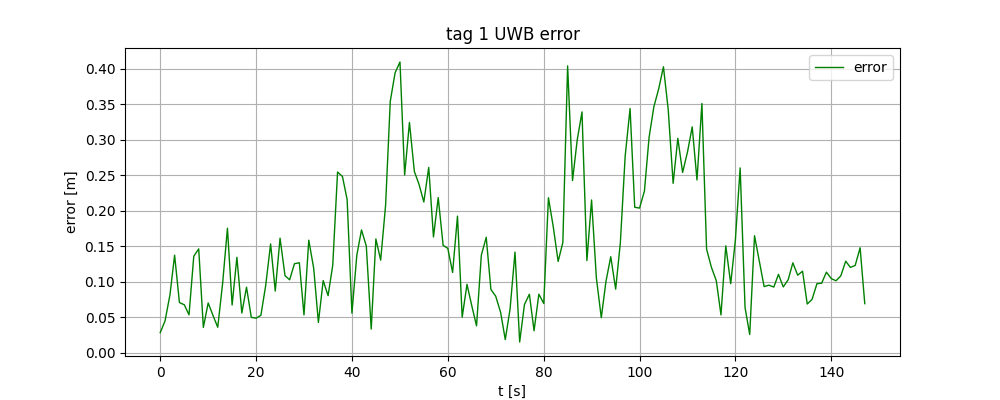

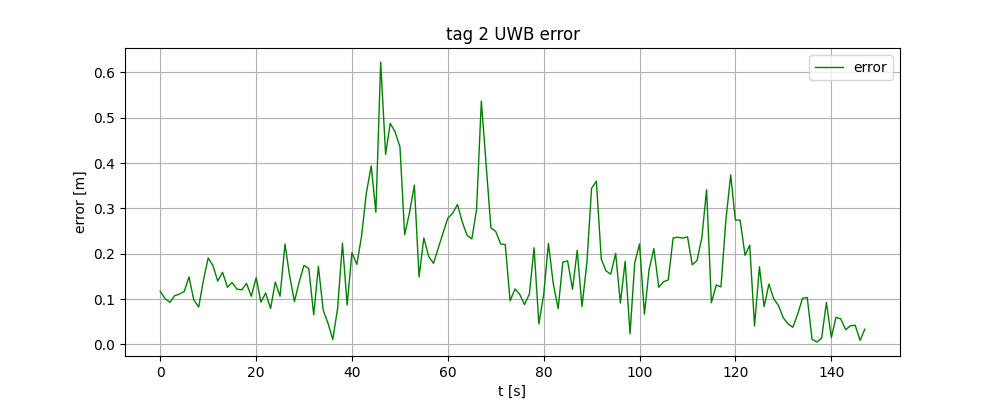

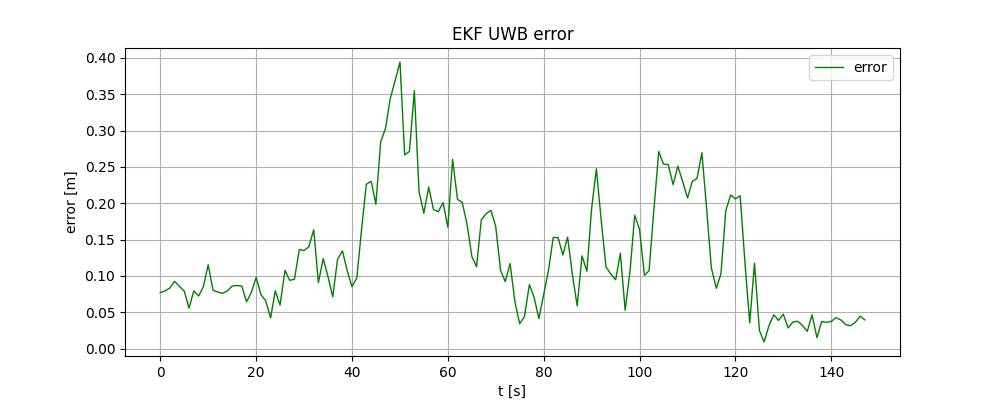

In [14]:
plot_error(
    title="tag 1 UWB error",
    plot_output_path=plot_output_path,
    t=tag_1_uwb_gts.t,
    a_x=tag_1_uwb_gts.x, a_y=tag_1_uwb_gts.y,
    b_x=tag_1_rtk_gts.x, b_y=tag_1_rtk_gts.y,
    color="green",
)
plot_error(
    title="tag 2 UWB error",
    plot_output_path=plot_output_path,
    t=tag_2_uwb_gts.t,
    a_x=tag_2_uwb_gts.x, a_y=tag_2_uwb_gts.y,
    b_x=tag_2_rtk_gts.x, b_y=tag_2_rtk_gts.y,
    color="green",
)
plot_error(
    title="EKF UWB error",
    plot_output_path=plot_output_path,
    t=ekf_uwb_gts.t,
    a_x=ekf_uwb_gts.x, a_y=ekf_uwb_gts.y,
    b_x=ekf_rtk_gts.x, b_y=ekf_rtk_gts.y,
    color="green",
)

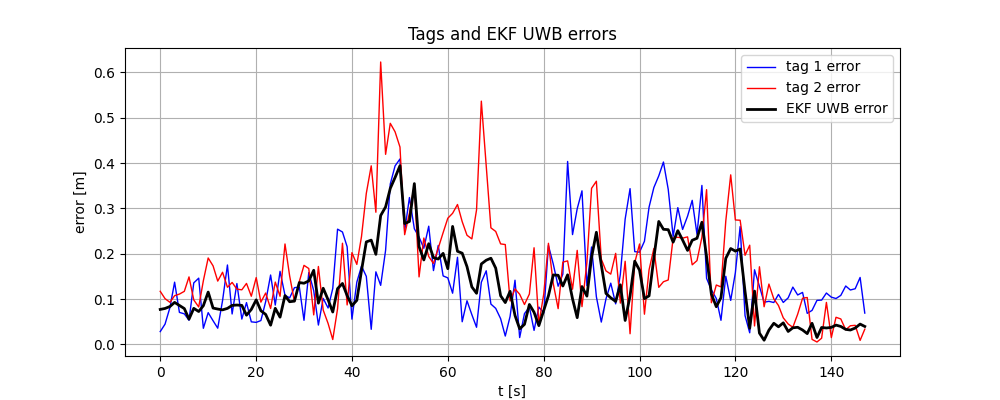

In [17]:
fig, ax = plt.subplots()
title = "Tags and EKF UWB errors"
ax.set_title(title)
ax.grid()
ax.set_xlabel("t [s]")
ax.set_ylabel("error [m]")
ax.plot(
    tag_1_uwb_gts.t - tag_1_uwb_gts.t.min(),
    np.sqrt((tag_1_uwb_gts.x - tag_1_rtk_gts.x)**2 + (tag_1_uwb_gts.y - tag_1_rtk_gts.y)**2),
    color="blue", label='tag 1 error', linewidth=1.0
)
ax.plot(
    tag_2_uwb_gts.t - tag_2_uwb_gts.t.min(),
    np.sqrt((tag_2_uwb_gts.x - tag_2_rtk_gts.x)**2 + (tag_2_uwb_gts.y - tag_2_rtk_gts.y)**2),
    color="red", label='tag 2 error', linewidth=1.0
)
ax.plot(
    ekf_uwb_gts.t - ekf_uwb_gts.t.min(),
    np.sqrt((ekf_uwb_gts.x - ekf_rtk_gts.x)**2 + (ekf_uwb_gts.y - ekf_rtk_gts.y)**2),
    color="black", label='EKF UWB error', linewidth=2.0
)
ax.legend()
fig.savefig(path.join(plot_output_path, f"error_{title.replace(' ', '_')}.png"), dpi=dpi)
fig.savefig(path.join(plot_output_path, f"error_{title.replace(' ', '_')}.svg"))
plt.show()


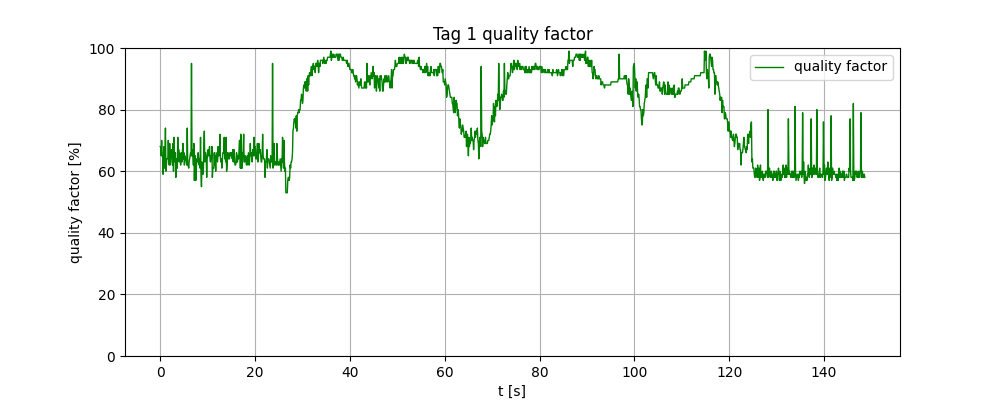

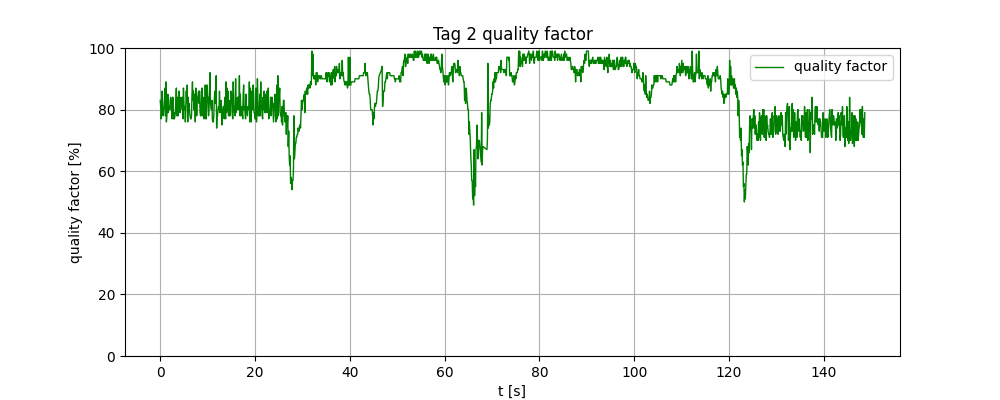

In [16]:
plot_quality(
    title="Tag 1 quality factor",
    d=tag_1, color="green",
    plot_output_path=plot_output_path,
)
plot_quality(
    title="Tag 2 quality factor",
    d=tag_2, color="green",
    plot_output_path=plot_output_path,
)